<a href="https://colab.research.google.com/github/LIBY70/Data-Analysis/blob/main/ida_week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab9: 상관분석 & 선형회귀

본 실습 자료는 『배워서 바로 써먹는 데이터 분석 with 파이썬』 (설진욱, 생능북스)의 내용을 참고하여 제작되었습니다.

## 0. 라이브러리 불러오기

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

### 한글 폰트 설정

In [6]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [7]:
import platform

if platform.system() == 'Darwin':       # macOS
    mpl.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':    # Windows
    mpl.rc('font', family='Malgun Gothic')
else:                                   # Linux / Colab
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    mpl.rc('font', family='NanumGothic')

mpl.rc('axes', unicode_minus=False)     # 마이너스 기호 깨짐 방지
print('폰트 설정 완료:', mpl.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


---
## PART 1. 상관분석 (Correlation Analysis)

두 변수가 **함께 변하는 경향**이 있는지를 수치로 표현.  
- **피어슨 상관계수 $r$**: $-1 \leq r \leq 1$, 선형 관계의 방향과 강도  
- 상관관계 ≠ 인과관계 — "함께 움직인다"는 사실만 말할 뿐

### 1-1. 데이터 준비 — 안면도 온실가스 관측 자료 (1999–2023)

국가 기후변화 대응 차원에서 측정한 온실가스 농도 데이터.  
월별 관측값을 **연간 평균**으로 집계해 사용.

In [8]:
df = pd.read_csv('1999-2023_ghgs.csv')
df['시간'] = pd.to_datetime(df['시간'])
df['연도'] = df['시간'].dt.year

print(f"원본 데이터: {df.shape[0]}행 × {df.shape[1]}열 (월별)")
df.head()

원본 데이터: 300행 × 10열 (월별)


,지점,시간,CO2_ppm,CH4_ppm,N2O_ppm,CFC11_ppm,CFC12_ppm,CFC113_ppm,SF6_ppm,연도
0,안면도,1999-01-01,373.1,NaN,NaN,NaN,NaN,NaN,NaN,1999
1,안면도,1999-02-01,374.0,NaN,315.2,266.9,534.1,NaN,NaN,1999
2,안면도,1999-03-01,374.9,NaN,314.6,267.5,535.1,NaN,NaN,1999
3,안면도,1999-04-01,375.1,1869.0,314.2,266.7,534.7,NaN,NaN,1999
4,안면도,1999-05-01,374.0,1863.0,314.6,268.6,535.1,NaN,NaN,1999


In [9]:
# 연간 평균 집계
annual = df.groupby('연도')[['CO2_ppm', 'CH4_ppm', 'N2O_ppm', 'SF6_ppm']].mean().reset_index()

print(f"연간 집계 데이터: {annual.shape[0]}년 (1999~2023)")

연간 집계 데이터: 25년 (1999~2023)


In [10]:
# 결측치 현황
annual.isnull().sum()

,0
연도,0
CO2_ppm,0
CH4_ppm,0
N2O_ppm,2
SF6_ppm,8


In [11]:
annual.round(4)

,연도,CO2_ppm,CH4_ppm,N2O_ppm,SF6_ppm
0,1999,371.1833,1861.0000,314.5909,NaN
1,2000,373.2833,1857.7000,314.8500,NaN
2,2001,375.6417,1851.3750,316.0250,NaN
3,2002,377.5750,1861.8333,318.3083,NaN
4,2003,379.9417,1874.3333,319.4000,NaN
5,2004,382.0917,1872.0000,NaN,NaN
6,2005,384.2667,1854.6667,NaN,NaN
7,2006,386.5250,1866.0833,321.6600,NaN
8,2007,388.5583,1889.7500,321.8500,6.3300
9,2008,390.7250,1889.4167,322.7083,6.6000


### 1-2. 피어슨 상관계수 계산

피어슨 상관계수 공식:

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2} \cdot \sqrt{\sum(y_i-\bar{y})^2}}$$

| $r$ 절댓값 범위 | 해석 |
|---|---|
| 0.9 ~ 1.0 | 매우 강한 상관 |
| 0.7 ~ 0.9 | 강한 상관 |
| 0.4 ~ 0.7 | 중간 상관 |
| 0.2 ~ 0.4 | 약한 상관 |
| 0.0 ~ 0.2 | 거의 없음 |

In [12]:
# pandas .corr(): 쌍별 완전 관측값(pairwise complete) 기준으로 계산
corr_matrix = annual[['CO2_ppm', 'CH4_ppm', 'N2O_ppm', 'SF6_ppm']].corr()
corr_matrix.round(4)

,CO2_ppm,CH4_ppm,N2O_ppm,SF6_ppm
CO2_ppm,1.0000,0.9833,0.9925,0.9893
CH4_ppm,0.9833,1.0000,0.9803,0.9829
N2O_ppm,0.9925,0.9803,1.0000,0.9705
SF6_ppm,0.9893,0.9829,0.9705,1.0000


In [13]:
# CO2와 각 가스 간의 상관계수 확인
gases = {'CH4_ppm': 'CH4(메탄)', 'N2O_ppm': 'N2O(아산화질소)', 'SF6_ppm': 'SF6(육불화황)'}

print(f"{'변수':<20} {'상관계수(r)':>12} {'해석':>15}")
print("-" * 60)
for col, label in gases.items():
    pair = annual[['CO2_ppm', col]].dropna()
    result = stats.pearsonr(pair['CO2_ppm'], pair[col])
    r = result.statistic
    if abs(r) >= 0.9:
        interp = '매우 강한 상관'
    elif abs(r) >= 0.7:
        interp = '강한 상관'
    elif abs(r) >= 0.4:
        interp = '중간 상관'
    elif abs(r) >= 0.2:
        interp = '약한 상관'
    else:
        interp = '거의 상관 없음'
    print(f"{'CO2 vs ' + label:<20} {r:>12.4f} {interp:>15}")

변수                        상관계수(r)              해석
------------------------------------------------------------
CO2 vs CH4(메탄)             0.9833        매우 강한 상관
CO2 vs N2O(아산화질소)          0.9925        매우 강한 상관
CO2 vs SF6(육불화황)           0.9893        매우 강한 상관


### 1-3. 상관분석의 가설검정

표본 상관계수 $r$이 **통계적으로 유의한지** 확인.

- $H_0$: $\rho = 0$ (선형 상관 없음)
- $H_1$: $\rho \neq 0$ (선형 상관 있음)
- 검정통계량: $t = \dfrac{r\sqrt{n-2}}{\sqrt{1-r^2}}$, 자유도 = $n - 2$

> **주의**: $n$이 크면 작은 $r$도 유의해질 수 있음 → $p$값과 $r$ 크기를 **함께** 해석

In [14]:
alpha = 0.05

print(f"{'변수':<20} {'r':>8} {'p값':>10} {'n':>5} {'결론':>20}")
print("-" * 68)
for col, label in gases.items():
    pair = annual[['CO2_ppm', col]].dropna()
    r, p = stats.pearsonr(pair['CO2_ppm'], pair[col])
    n = len(pair)
    conclusion = 'H0 기각 (유의한 상관)' if p <= alpha else 'H0 기각 실패'
    print(f"{'CO2 vs ' + label:<20} {r:>8.4f} {p:>10.4f} {n:>5} {conclusion:>20}")

변수                          r         p값     n                   결론
--------------------------------------------------------------------
CO2 vs CH4(메탄)         0.9833     0.0000    25       H0 기각 (유의한 상관)
CO2 vs N2O(아산화질소)      0.9925     0.0000    23       H0 기각 (유의한 상관)
CO2 vs SF6(육불화황)       0.9893     0.0000    17       H0 기각 (유의한 상관)


### 1-4. 시각화 — 산점도 & 상관 히트맵

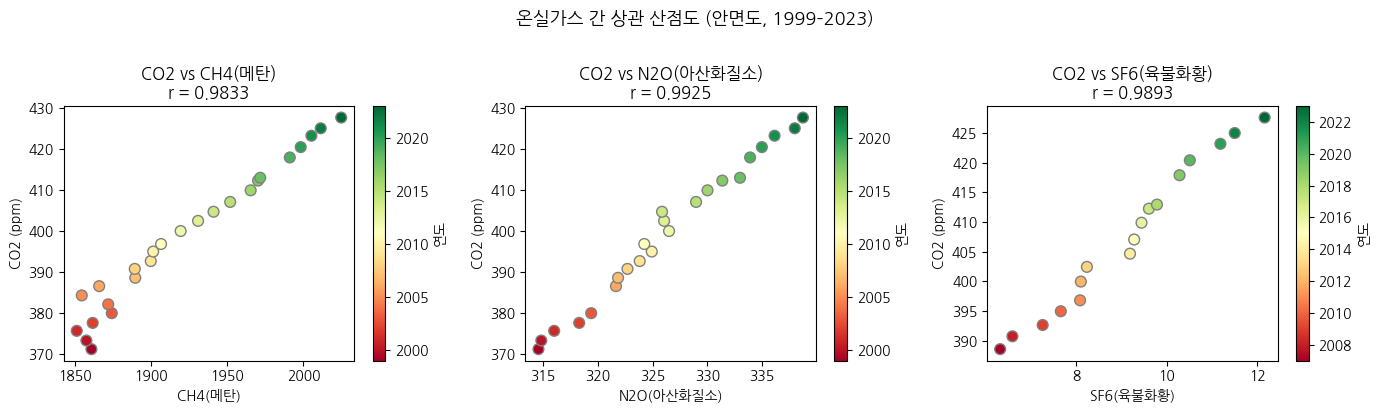

In [15]:
# CO2 vs 각 가스 산점도
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, label) in zip(axes, gases.items()):
    pair = annual[['CO2_ppm', col, '연도']].dropna()
    r, _ = stats.pearsonr(pair['CO2_ppm'], pair[col])
    sc = ax.scatter(pair[col], pair['CO2_ppm'],
                    c=pair['연도'], cmap='RdYlGn', edgecolors='gray', s=60)
    plt.colorbar(sc, ax=ax, label='연도')
    ax.set_xlabel(label)
    ax.set_ylabel('CO2 (ppm)')
    ax.set_title(f'CO2 vs {label}\nr = {r:.4f}')

plt.suptitle('온실가스 간 상관 산점도 (안면도, 1999–2023)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

히트맵 기준 연도 수: 17개 (SF6 관측 시작 이후)


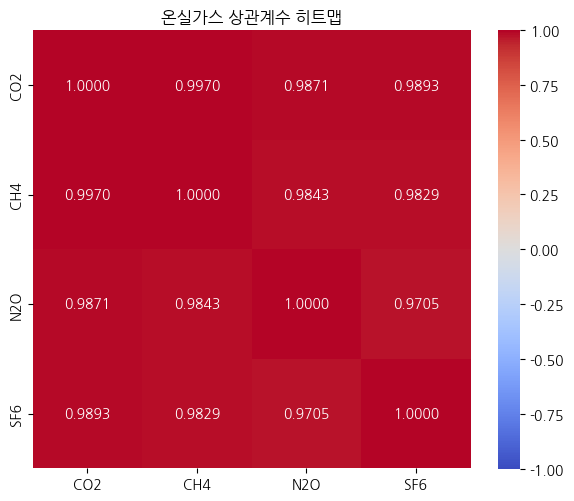

In [16]:
# 상관계수 히트맵 (4개 변수 모두 있는 17개 연도 기준)
corr_df = annual[['CO2_ppm', 'CH4_ppm', 'N2O_ppm', 'SF6_ppm']].dropna()
print(f"히트맵 기준 연도 수: {len(corr_df)}개 (SF6 관측 시작 이후)")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.4f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=['CO2', 'CH4', 'N2O', 'SF6'],
            yticklabels=['CO2', 'CH4', 'N2O', 'SF6'])
ax.set_title('온실가스 상관계수 히트맵')
plt.tight_layout()
plt.show()

---
## PART 2. 단순선형회귀 (Simple Linear Regression)

독립변수 $X$로 종속변수 $Y$를 **예측하는 함수**를 추정.

$$Y = \beta_0 + \beta_1 X + \epsilon, \quad \epsilon \sim N(0, \sigma^2)$$

**최소자승법(OLS)**: 잔차 제곱합 $\sum(y_i - \hat{y}_i)^2$ 을 최소화하는 $\hat{\beta}_0$, $\hat{\beta}_1$ 추정

$$\hat{\beta}_1 = \frac{S_{XY}}{S_{XX}} = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2}, \quad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### 2-1. 회귀모형 추정 — 연도 → CO2 농도

**연구 질문**: 연도(시간)가 1년 증가할 때 CO2 농도는 평균 얼마나 증가하는가?

In [17]:
# statsmodels OLS: formula 방식으로 직관적 지정
# '종속변수 ~ 독립변수' 형식
model = smf.ols('CO2_ppm ~ 연도', data=annual).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                CO2_ppm   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     9165.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.99e-31
Time:                        00:07:25   Log-Likelihood:                -31.331
No. Observations:                  25   AIC:                             66.66
Df Residuals:                      23   BIC:                             69.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -4318.4747     49.270    -87.650      0.0

### 2-2. 회귀결과표 읽기

summary() 결과에서 핵심 항목만 추출해 해석.

| 항목 | 의미 |
|---|---|
| coef (Intercept) | $\hat{\beta}_0$ : $X=0$일 때 $Y$의 예측값 |
| coef (연도) | $\hat{\beta}_1$ : 연도가 1 증가할 때 CO2의 평균 변화량 |
| $P>|t|$ | 회귀계수의 유의성 — 0.05 이하면 유의함 |
| $R^2$ | 설명력 |
| F-statistic | 전체 모형 유의성 |

In [18]:
b0 = model.params['Intercept']
b1 = model.params['연도']
r2 = model.rsquared
p_b1 = model.pvalues['연도']

print(f"추정 회귀식: CO2 = {b0:.2f} + {b1:.4f} × 연도")
print()
print(f"β1 = {b1:.4f}  → 연도가 1년 증가할 때 CO2 농도 평균 {b1:.4f} ppm 증가")
print(f"β1 p값 = {p_b1:.2e}  → 연도는 CO2를 유의하게 설명함 (p < 0.05)")
print(f"R² = {r2:.4f}  → 연도가 CO2 변동의 {r2*100:.2f}%를 설명")

추정 회귀식: CO2 = -4318.47 + 2.3455 × 연도

β1 = 2.3455  → 연도가 1년 증가할 때 CO2 농도 평균 2.3455 ppm 증가
β1 p값 = 1.99e-31  → 연도는 CO2를 유의하게 설명함 (p < 0.05)
R² = 0.9975  → 연도가 CO2 변동의 99.75%를 설명


### 2-3. 새 데이터 예측

In [19]:
# 2025, 2030년 CO2 농도 예측
future = pd.DataFrame({'연도': [2025, 2030]})
pred = model.predict(future)

for yr, ppm in zip(future['연도'], pred):
    print(f"{yr}년 CO2 예측: {ppm:.2f} ppm")

print()
print("※ 관측 범위(1999~2023)를 크게 벗어난 예측은 신뢰도가 낮음 (외삽 주의)")

2025년 CO2 예측: 431.12 ppm
2030년 CO2 예측: 442.85 ppm

※ 관측 범위(1999~2023)를 크게 벗어난 예측은 신뢰도가 낮음 (외삽 주의)


### 2-4. 회귀선 시각화

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_69590/2552117464.py:11: SyntaxWarning: invalid escape sequence '\h'
  label=f'회귀선: $\hat{{Y}}$ = {b0:.1f} + {b1:.4f}X')


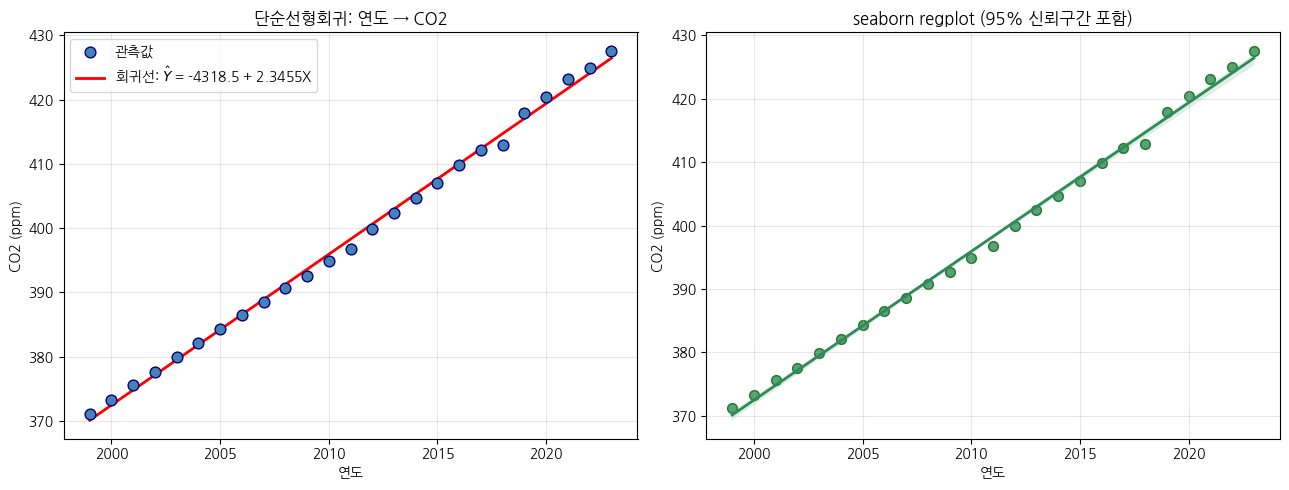

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- 왼쪽: 회귀선 + 산점도 ---
ax = axes[0]
ax.scatter(annual['연도'], annual['CO2_ppm'],
           color='steelblue', edgecolors='navy', s=60, zorder=3, label='관측값')

x_line = np.linspace(annual['연도'].min(), annual['연도'].max(), 200)
y_line = model.predict(pd.DataFrame({'연도': x_line}))
ax.plot(x_line, y_line, color='red', linewidth=2,
        label=f'회귀선: $\hat{{Y}}$ = {b0:.1f} + {b1:.4f}X')

ax.set_xlabel('연도')
ax.set_ylabel('CO2 (ppm)')
ax.set_title('단순선형회귀: 연도 → CO2')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 오른쪽: seaborn regplot (신뢰구간 포함) ---
ax2 = axes[1]
sns.regplot(data=annual, x='연도', y='CO2_ppm',
            ax=ax2, color='seagreen',
            scatter_kws={'s': 50, 'edgecolors': 'darkgreen'},
            line_kws={'linewidth': 2})
ax2.set_xlabel('연도')
ax2.set_ylabel('CO2 (ppm)')
ax2.set_title('seaborn regplot (95% 신뢰구간 포함)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## PART 3. 회귀모형 평가

| 지표 | 의미 | 수식 |
|---|---|---|
| $R^2$ | 설명력 | $\frac{SSR}{SST}$ |
| **RSE** | 예측 오차 크기 ($Y$와 같은 단위) | $\sqrt{\frac{SSE}{n-2}}$ |
| **F-검정** | 전체 모형 유의성 | — |

### 3-1. 결정계수 $R^2$ & RSE

In [21]:
r2     = model.rsquared
r2_adj = model.rsquared_adj
rse    = model.mse_resid ** 0.5          # RSE = √MSE_resid
f_val  = model.fvalue
f_p    = model.f_pvalue

print(f"R²        = {r2:.4f}  → 연도가 CO2 변동의 {r2*100:.2f}%를 설명")
print(f"조정 R²   = {r2_adj:.4f}")
print(f"RSE       = {rse:.4f} ppm  → 예측값과 실제값의 평균 오차 약 {rse:.2f} ppm")
print(f"F-통계량  = {f_val:.2f}  (p = {f_p:.2e})  → 모형 전체가 유의함")

R²        = 0.9975  → 연도가 CO2 변동의 99.75%를 설명
조정 R²   = 0.9974
RSE       = 0.8834 ppm  → 예측값과 실제값의 평균 오차 약 0.88 ppm
F-통계량  = 9164.97  (p = 1.99e-31)  → 모형 전체가 유의함


In [22]:
# 분산 분해 직접 확인: SST = SSR + SSE
y     = annual['CO2_ppm']
y_hat = model.fittedvalues
y_bar = y.mean()

SST = ((y - y_bar) ** 2).sum()
SSR = ((y_hat - y_bar) ** 2).sum()
SSE = ((y - y_hat) ** 2).sum()

print(f"SST (전체 변동)      = {SST:.2f}")
print(f"SSR (설명된 변동)    = {SSR:.2f}  ({SSR/SST*100:.2f}%)")
print(f"SSE (설명 안 된 변동)= {SSE:.2f}  ({SSE/SST*100:.2f}%)")
print(f"R² = SSR/SST = {SSR/SST:.4f}")

SST (전체 변동)      = 7169.60
SSR (설명된 변동)    = 7151.65  (99.75%)
SSE (설명 안 된 변동)= 17.95  (0.25%)
R² = SSR/SST = 0.9975


### 3-2. 잔차 분석 (Residual Analysis)

회귀 기본 가정 확인: **선형성 · 등분산성 · 독립성 · 정규성**

- 잔차 - 적합값 산점도
    - 무작위 패턴 → 선형성/등분산 가정 만족
    - 곡선 패턴 → 선형성 위반 / 깔때기 패턴 → 등분산 위반

<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_69590/65094167.py:9: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel('적합값 ($\hat{Y}$)')


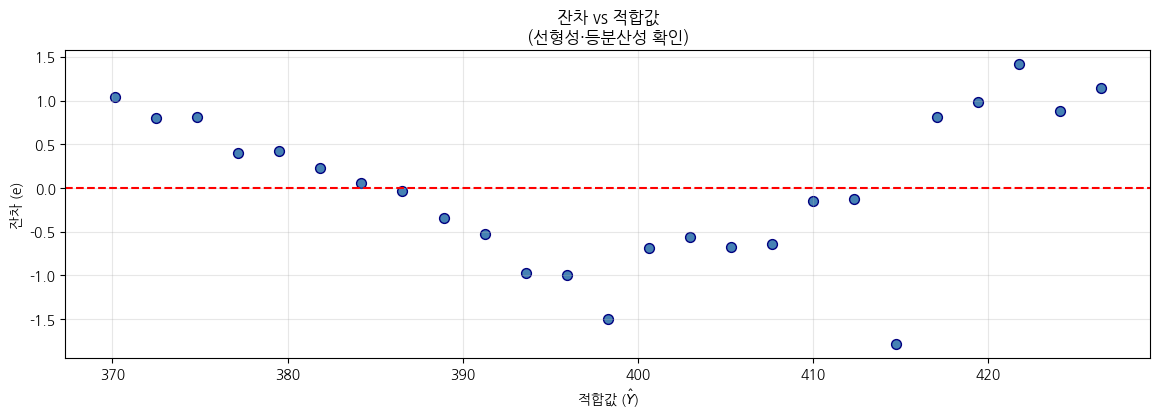

In [23]:
residuals = model.resid

fig, ax = plt.subplots(figsize=(14, 4))

# 잔차 - 적합값
ax.scatter(model.fittedvalues, residuals,
           color='steelblue', edgecolors='navy', s=50)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('적합값 ($\hat{Y}$)')
ax.set_ylabel('잔차 (e)')
ax.set_title('잔차 vs 적합값\n(선형성·등분산성 확인)')
ax.grid(True, alpha=0.3)

---
## PART 4. 다중선형회귀 (Multiple Linear Regression)

독립변수가 **2개 이상**인 회귀모형.

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_k X_k + \epsilon$$

- $\beta_j$ (**편회귀계수**): 다른 변수를 고정할 때, $X_j$ 1단위 증가에 따른 $Y$의 평균 변화
- 단순 회귀와 달리 **조정 $R^2$** (Adjusted $R^2$)로 모형 비교

### 4-1. 다중회귀모형 추정 — CO2 ~ CH4 + N2O

CH4(메탄)과 N2O(아산화질소) 농도로 CO2 농도를 예측.

In [24]:
# N2O가 있는 연도만 사용 (23개 연도)
annual_multi = annual.dropna(subset=['N2O_ppm']).copy()
print(f"다중회귀 사용 데이터: {len(annual_multi)}개 연도")
# print(annual_multi[['연도', 'CO2_ppm', 'CH4_ppm', 'N2O_ppm']].to_string(index=False))
# annual_multi
annual_multi[['연도', 'CO2_ppm', 'CH4_ppm', 'N2O_ppm']]

다중회귀 사용 데이터: 23개 연도


,연도,CO2_ppm,CH4_ppm,N2O_ppm
0,1999,371.183333,1861.000000,314.590909
1,2000,373.283333,1857.700000,314.850000
2,2001,375.641667,1851.375000,316.025000
3,2002,377.575000,1861.833333,318.308333
4,2003,379.941667,1874.333333,319.400000
7,2006,386.525000,1866.083333,321.660000
8,2007,388.558333,1889.750000,321.850000
9,2008,390.725000,1889.416667,322.708333
10,2009,392.625000,1899.916667,323.825000
11,2010,394.941667,1901.500000,324.925000


In [25]:
model_multi = smf.ols('CO2_ppm ~ CH4_ppm + N2O_ppm', data=annual_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                CO2_ppm   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     911.4
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.27e-20
Time:                        00:07:26   Log-Likelihood:                -45.823
No. Observations:                  23   AIC:                             97.65
Df Residuals:                      20   BIC:                             101.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -322.9795     26.622    -12.132      0.0

In [26]:
b_ch4 = model_multi.params['CH4_ppm']
b_n2o = model_multi.params['N2O_ppm']
b_int = model_multi.params['Intercept']

print(f"추정 회귀식:")
print(f"  CO2 = {b_int:.2f} + {b_ch4:.4f}×CH4 + {b_n2o:.4f}×N2O")
print()
print(f"편회귀계수 해석 (다른 변수를 고정할 때):")
print(f"  CH4 1 ppm 증가 → CO2 평균 {b_ch4:.4f} ppm 증가")
print(f"  N2O 1 ppm 증가 → CO2 평균 {b_n2o:.4f} ppm 증가")

추정 회귀식:
  CO2 = -322.98 + 0.1013×CH4 + 1.6155×N2O

편회귀계수 해석 (다른 변수를 고정할 때):
  CH4 1 ppm 증가 → CO2 평균 0.1013 ppm 증가
  N2O 1 ppm 증가 → CO2 평균 1.6155 ppm 증가


### 4-2. 조정 $R^2$ — 단순 vs 다중 회귀 비교

변수 개수가 늘어나면 $R^2$는 항상 증가하거나 유지 → **조정 $R^2$**로 비교.

$$\text{Adjusted } R^2 = 1 - \frac{(1-R^2)(n-1)}{n-k-1}$$

조정 $R^2$가 감소하면 추가한 변수가 모형에 기여하지 않음.

In [27]:
# 단순회귀 (연도만, 같은 23개 연도 기준)
model_simple_23 = smf.ols('CO2_ppm ~ 연도', data=annual_multi).fit()
model_ch4_only  = smf.ols('CO2_ppm ~ CH4_ppm', data=annual_multi).fit()
model_n2o_only  = smf.ols('CO2_ppm ~ N2O_ppm', data=annual_multi).fit()

models = {
    '단순: CO2 ~ 연도': model_simple_23,
    '단순: CO2 ~ CH4': model_ch4_only,
    '단순: CO2 ~ N2O': model_n2o_only,
    '다중: CO2 ~ CH4 + N2O': model_multi,
}

print(f"{'모형':<28} {'R²':>8} {'조정 R²':>10} {'RSE':>8}")
print("-" * 58)
for name, m in models.items():
    rse_m = m.mse_resid ** 0.5
    print(f"{name:<28} {m.rsquared:>8.4f} {m.rsquared_adj:>10.4f} {rse_m:>8.4f}")

모형                                 R²      조정 R²      RSE
----------------------------------------------------------
단순: CO2 ~ 연도                   0.9973     0.9972   0.9229
단순: CO2 ~ CH4                  0.9714     0.9701   3.0120
단순: CO2 ~ N2O                  0.9850     0.9843   2.1796
다중: CO2 ~ CH4 + N2O            0.9891     0.9881   1.9027


### 4-3. 다중공선성 진단 — VIF

독립변수 사이에 **강한 선형 관계**가 있을 때 발생하는 문제.
- 회귀계수 표준오차 증가, 개별 t-검정 신뢰 불가
- VIF(분산팽창인수): $\text{VIF}(X_j) = \dfrac{1}{1-R_j^2}$  
  ($R_j^2$: $X_j$를 나머지 독립변수들로 회귀했을 때의 결정계수)

| VIF 값 | 해석 |
|---|---|
| 1 | 다중공선성 없음 |
| 1 ~ 5 | 낮은 수준 (양호) |
| 5 ~ 10 | 중간 수준 (주의) |
| > 10 | 심각한 다중공선성 |

In [28]:
from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# variance_inflation_factor는 상수항 포함 설계행렬을 기대함
X_vif = add_constant(annual_multi[['CH4_ppm', 'N2O_ppm']])
X_vif

,const,CH4_ppm,N2O_ppm
0,1.0,1861.000000,314.590909
1,1.0,1857.700000,314.850000
2,1.0,1851.375000,316.025000
3,1.0,1861.833333,318.308333
4,1.0,1874.333333,319.400000
7,1.0,1866.083333,321.660000
8,1.0,1889.750000,321.850000
9,1.0,1889.416667,322.708333
10,1.0,1899.916667,323.825000
11,1.0,1901.500000,324.925000


In [29]:
vif_data = pd.DataFrame({
    '변수': ['CH4_ppm', 'N2O_ppm'],
    'VIF': [variance_inflation_factor(X_vif.values, i + 1) for i in range(2)]
})
vif_data['판정'] = vif_data['VIF'].apply(
    lambda v: '심각' if v > 10 else ('주의' if v > 5 else '양호')
)
vif_data.round(2)

,변수,VIF,판정
0,CH4_ppm,25.68,심각
1,N2O_ppm,25.68,심각


In [30]:
# 이유: CH4와 N2O 모두 시간에 따라 증가 → 서로 강한 상관
r_ch4_n2o, _ = stats.pearsonr(
    annual_multi['CH4_ppm'], annual_multi['N2O_ppm']
)
print(f"CH4 vs N2O 상관계수: r = {r_ch4_n2o:.4f}")
print(f"→ VIF = 1 / (1 - {r_ch4_n2o:.4f}²) ≈ {1/(1-r_ch4_n2o**2):.1f}")

CH4 vs N2O 상관계수: r = 0.9803
→ VIF = 1 / (1 - 0.9803²) ≈ 25.7


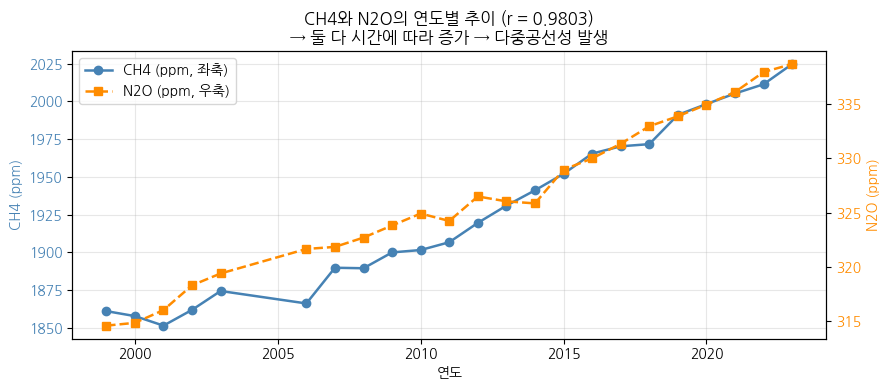

In [31]:
# CH4, N2O의 연도별 추이 — 둘 다 시간에 따라 증가하는 패턴 시각화
fig, ax = plt.subplots(figsize=(9, 4))

color1, color2 = 'steelblue', 'darkorange'
ax.plot(annual_multi['연도'], annual_multi['CH4_ppm'],
        'o-', color=color1, label='CH4 (ppm, 좌축)', linewidth=1.8)
ax.set_xlabel('연도')
ax.set_ylabel('CH4 (ppm)', color=color1)
ax.tick_params(axis='y', labelcolor=color1)

ax2 = ax.twinx()
ax2.plot(annual_multi['연도'], annual_multi['N2O_ppm'],
         's--', color=color2, label='N2O (ppm, 우축)', linewidth=1.8)
ax2.set_ylabel('N2O (ppm)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax.set_title(f'CH4와 N2O의 연도별 추이 (r = {r_ch4_n2o:.4f})\n→ 둘 다 시간에 따라 증가 → 다중공선성 발생')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 요약

### 핵심 개념

| 개념 | 설명 | 주요 함수 |
|---|---|---|
| 피어슨 상관계수 $r$ | 선형 관계 방향·강도 ($-1 \leq r \leq 1$) | `df.corr()`, `stats.pearsonr()` |
| 상관분석 가설검정 | $H_0$: $\rho=0$, $p \leq 0.05$면 유의한 상관 | `stats.pearsonr()` |
| 단순선형회귀 | $\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X$ (OLS) | `smf.ols().fit()` |
| $R^2$ | 회귀선이 $Y$ 변동의 몇 %를 설명 | `model.rsquared` |
| RSE | 예측 오차 크기 ($Y$와 같은 단위) | `model.mse_resid**0.5` |
| 다중회귀 | 독립변수 2개 이상, 조정 $R^2$ 사용 | `smf.ols('Y ~ X1 + X2')` |
| VIF | 다중공선성 진단 — $\text{VIF} > 10$이면 심각 | `variance_inflation_factor()` |

### 실습 데이터 결과 요약

- **CO2 vs 연도 단순회귀**: $R^2 = 0.9975$ → 연도만으로 CO2 변동의 99.75% 설명
- **CO2, CH4, N2O, SF6**: 모두 $r > 0.98$의 매우 강한 상관 — 시간에 따른 공통 증가 추세 때문
- **다중회귀 VIF**: CH4·N2O $\text{VIF} \approx 15{,}000$ → 극심한 다중공선성 (두 변수 모두 시간의 대리변수)

> **상관 ≠ 인과**: 모든 온실가스가 함께 증가하는 것은 산업화·인간 활동이라는 **공통 원인** 때문